<a href="https://colab.research.google.com/github/hariharan-vs/Deep-learning-lab/blob/main/24BAD030__EX5_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# EXPERIMENT 5 — IMPLEMENTATION OF RNN FOR TEXT GENERATION
# Name: Hariharan V S
# Roll No: 24BAD030


In [2]:
# STEP 1: IMPORT LIBRARIES
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


In [3]:
# STEP 2: DOWNLOAD TINY SHAKESPEARE DATASET
!wget -q https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
print("Tiny Shakespeare dataset downloaded successfully.")


Tiny Shakespeare dataset downloaded successfully.


In [4]:
# STEP 3: LOAD AND EXPLORE DATASET
with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

print("Number of characters:", len(text))
print("\n----- SAMPLE TEXT -----\n")
print(text[:1000])


Number of characters: 1115394

----- SAMPLE TEXT -----

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
spea

In [5]:
# STEP 4: CONVERT TEXT TO LOWERCASE
text = text.lower()

print("Text converted to lowercase.")
print(text[:500])


Text converted to lowercase.
first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


In [6]:
# STEP 5: TOKENIZATION
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("Total vocabulary size:", total_words)

print("\nFirst 20 words and their indexes:")
for word, index in list(tokenizer.word_index.items())[:20]:
    print(word, ":", index)


Total vocabulary size: 12633

First 20 words and their indexes:
the : 1
and : 2
to : 3
i : 4
of : 5
you : 6
my : 7
a : 8
that : 9
in : 10
is : 11
not : 12
for : 13
with : 14
me : 15
it : 16
be : 17
your : 18
his : 19
but : 20


In [7]:
# STEP 6: CONVERT TEXT INTO NUMERICAL SEQUENCES
sequences = tokenizer.texts_to_sequences([text])[0]

print("First 50 numerical tokens:")
print(sequences[:50])


First 50 numerical tokens:
[88, 269, 139, 35, 969, 143, 668, 127, 15, 102, 33, 102, 102, 88, 269, 6, 40, 33, 1268, 350, 3, 199, 63, 3, 3332, 33, 1268, 1268, 88, 269, 88, 6, 91, 1141, 231, 11, 2274, 580, 3, 1, 305, 33, 35, 2555, 35, 2555, 88, 269, 70, 78]


In [8]:
# STEP 7: GENERATE INPUT SEQUENCES
input_sequences = []

for line in text.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i + 1]
        input_sequences.append(n_gram_sequence)

print("Total input sequences:", len(input_sequences))


Total input sequences: 171312


In [9]:
# STEP 8: LIMIT SEQUENCES TO PREVENT RAM CRASH
MAX_SEQUENCES = 100000

if len(input_sequences) > MAX_SEQUENCES:
    input_sequences = input_sequences[:MAX_SEQUENCES]

print("Sequences used:", len(input_sequences))


Sequences used: 100000


In [10]:
# STEP 9: APPLY PADDING
max_sequence_len = max(len(x) for x in input_sequences)

print("Maximum sequence length:", max_sequence_len)

input_sequences = np.array(
    pad_sequences(
        input_sequences,
        maxlen=max_sequence_len,
        padding="pre"
    ),
    dtype=np.int32
)

print("Padded data shape:", input_sequences.shape)


Maximum sequence length: 16
Padded data shape: (100000, 16)


In [11]:
# STEP 10: CREATE INPUT X AND TARGET Y
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

# IMPORTANT:
# Do not use to_categorical() here.
# Integer labels use much less RAM.


X shape: (100000, 15)
y shape: (100000,)


In [12]:
# STEP 11: TRAINING AND VALIDATION SPLIT
split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_val = X[split:]
y_val = y[split:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))


Training samples: 80000
Validation samples: 20000


In [13]:
# PART B — STEP 12: CREATE RNN MODEL
model = Sequential()

model.add(
    Embedding(
        input_dim=total_words,
        output_dim=64
    )
)

model.add(
    SimpleRNN(64)
)

model.add(
    Dense(
        total_words,
        activation="softmax"
    )
)

print("RNN model created successfully.")


RNN model created successfully.


In [14]:
# STEP 13: DISPLAY MODEL SUMMARY
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
# STEP 14: COMPILE THE MODEL
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")


Model compiled successfully.


In [17]:
# PART C — STEP 15: TRAIN THE MODEL
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - accuracy: 0.0975 - loss: 5.8806 - val_accuracy: 0.0757 - val_loss: 6.5559
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 69ms/step - accuracy: 0.1069 - loss: 5.6830 - val_accuracy: 0.0768 - val_loss: 6.5499
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 78ms/step - accuracy: 0.1147 - loss: 5.5155 - val_accuracy: 0.0801 - val_loss: 6.5615
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 69ms/step - accuracy: 0.1227 - loss: 5.3674 - val_accuracy: 0.0804 - val_loss: 6.6014
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.1303 - loss: 5.2345 - val_accuracy: 0.0834 - val_loss: 6.6247


In [18]:
# STEP 16: DISPLAY FINAL RESULTS
print("Training Accuracy:",
      history.history["accuracy"][-1])

print("Validation Accuracy:",
      history.history["val_accuracy"][-1])

print("Training Loss:",
      history.history["loss"][-1])

print("Validation Loss:",
      history.history["val_loss"][-1])


Training Accuracy: 0.13032500445842743
Validation Accuracy: 0.08344999700784683
Training Loss: 5.234517574310303
Validation Loss: 6.624727249145508


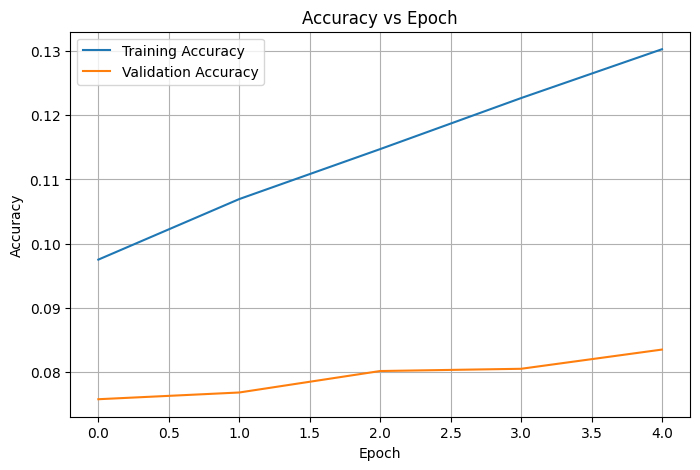

In [19]:
# STEP 17: ACCURACY VS EPOCH
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


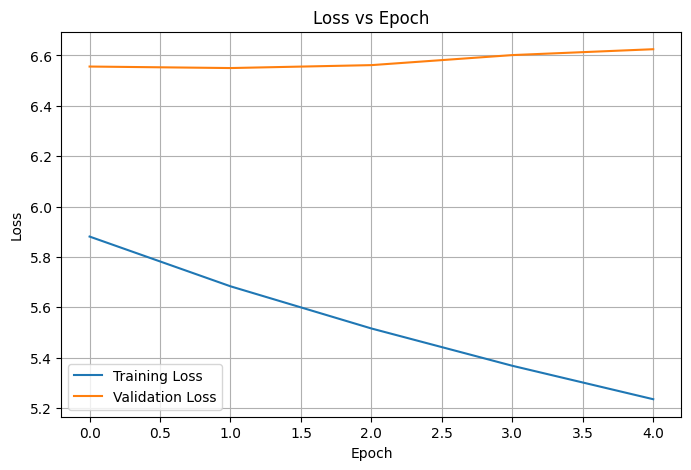

In [20]:
# STEP 18: LOSS VS EPOCH
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
# PART D — STEP 19: TEXT GENERATION FUNCTION
def generate_text(seed_text, next_words):

    generated_text = seed_text

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [generated_text]
        )[0]

        token_list = token_list[
            -(max_sequence_len - 1):
        ]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len - 1,
            padding="pre"
        )

        predicted = model.predict(
            token_list,
            verbose=0
        )

        predicted_word_index = np.argmax(
            predicted,
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break

        if output_word:
            generated_text += " " + output_word

    return generated_text


In [22]:
# STEP 20: GENERATE TEXT — SAMPLE 1
seed_text = "the king"

generated_text = generate_text(
    seed_text,
    20
)

print("Seed:")
print(seed_text)

print("\nGenerated Text:")
print(generated_text)


Seed:
the king

Generated Text:
the king of rome and all the world of death and all the king of rome and all the king of rome


In [24]:
# STEP 21: GENERATE TEXT — SAMPLE 2
seed_text = "my lord"

generated_text = generate_text(
    seed_text,
    20
)

print("Seed:")
print(seed_text)

print("\nGenerated Text:")
print(generated_text)


Seed:
my lord

Generated Text:
my lord of rome and all the world of death and all the king of rome and all the king of rome


In [25]:
# STEP 22: GENERATE TEXT — SAMPLE 3
seed_text = "love is"

generated_text = generate_text(
    seed_text,
    20
)

print("Seed:")
print(seed_text)

print("\nGenerated Text:")
print(generated_text)


Seed:
love is

Generated Text:
love is the people that i am not to be a thousand and that i am not to be a man to


In [26]:
# STEP 23: GENERATE TEXT — SAMPLE 4
seed_text = "to be"

generated_text = generate_text(
    seed_text,
    20
)

print("Seed:")
print(seed_text)

print("\nGenerated Text:")
print(generated_text)


Seed:
to be

Generated Text:
to be a thousand and that i am not to be a thousand and that i am not to be a man


In [27]:
# FINAL OBSERVATION
print(
    "The RNN learned sequential patterns from the Tiny Shakespeare "
    "dataset and generated text by predicting the next word from "
    "given seed sentences. Some outputs were coherent and some "
    "were not grammatically or contextually perfect."
)


The RNN learned sequential patterns from the Tiny Shakespeare dataset and generated text by predicting the next word from given seed sentences. Some outputs were coherent and some were not grammatically or contextually perfect.
